In [3]:
import pandas as pd

data = pd.read_csv("export (2).csv")

data.head()

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2020-01-01 00:00:00,7.8,-0.3,11.0,1.8,NaN,NaN,5.3,NaN,1032.2,NaN
1,2020-01-02 00:00:00,9.7,1.2,11.3,0.0,NaN,NaN,4.9,NaN,1028.3,NaN
2,2020-01-03 00:00:00,9.3,7.4,11.3,4.3,NaN,NaN,6.7,NaN,1027.3,NaN
3,2020-01-04 00:00:00,9.6,8.7,10.1,NaN,NaN,NaN,6.8,NaN,1026.4,NaN
4,2020-01-05 00:00:00,12.4,9.5,17.0,0.0,NaN,NaN,8.2,NaN,1024.7,NaN


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2192 non-null   str    
 1   tavg    2192 non-null   float64
 2   tmin    2192 non-null   float64
 3   tmax    2192 non-null   float64
 4   prcp    1864 non-null   float64
 5   snow    27 non-null     float64
 6   wdir    0 non-null      float64
 7   wspd    2192 non-null   float64
 8   wpgt    0 non-null      float64
 9   pres    2192 non-null   float64
 10  tsun    0 non-null      float64
dtypes: float64(10), str(1)
memory usage: 188.5 KB


In [5]:
data.describe()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
count,2192.000000,2192.000000,2192.000000,1864.00000,27.000000,0.0,2192.000000,0.0,2192.000000,0.0
mean,18.957117,14.927053,24.473768,4.54367,1.222222,NaN,9.394343,NaN,1015.892838,NaN
std,9.085648,9.021228,9.497898,11.81296,0.800641,NaN,3.240340,NaN,9.327848,NaN
min,-3.300000,-6.400000,1.600000,0.00000,1.000000,NaN,2.200000,NaN,987.000000,NaN
25%,10.800000,7.000000,16.775000,0.00000,1.000000,NaN,7.000000,NaN,1007.800000,NaN
50%,19.400000,15.250000,25.000000,0.00000,1.000000,NaN,8.750000,NaN,1015.750000,NaN
75%,26.900000,23.000000,32.700000,3.02500,1.000000,NaN,11.025000,NaN,1023.300000,NaN
max,35.900000,31.000000,42.000000,127.60000,5.000000,NaN,30.300000,NaN,1042.900000,NaN


In [7]:
data = data.drop(
    columns=["snow","wdir","wpgt","tsun"]
)

data.head()

,date,tavg,tmin,tmax,prcp,wspd,pres
0,2020-01-01 00:00:00,7.8,-0.3,11.0,1.8,5.3,1032.2
1,2020-01-02 00:00:00,9.7,1.2,11.3,0.0,4.9,1028.3
2,2020-01-03 00:00:00,9.3,7.4,11.3,4.3,6.7,1027.3
3,2020-01-04 00:00:00,9.6,8.7,10.1,NaN,6.8,1026.4
4,2020-01-05 00:00:00,12.4,9.5,17.0,0.0,8.2,1024.7


In [8]:
data["date"] = pd.to_datetime(data["date"])

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2192 non-null   datetime64[us]
 1   tavg    2192 non-null   float64       
 2   tmin    2192 non-null   float64       
 3   tmax    2192 non-null   float64       
 4   prcp    1864 non-null   float64       
 5   wspd    2192 non-null   float64       
 6   pres    2192 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 120.0 KB


In [9]:
data = data.fillna(0)

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2192 non-null   datetime64[us]
 1   tavg    2192 non-null   float64       
 2   tmin    2192 non-null   float64       
 3   tmax    2192 non-null   float64       
 4   prcp    2192 non-null   float64       
 5   wspd    2192 non-null   float64       
 6   pres    2192 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 120.0 KB


In [10]:
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day

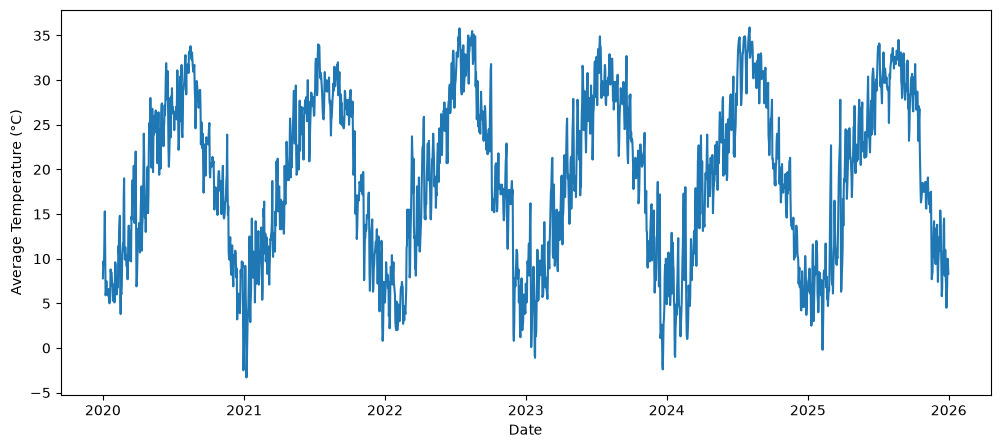

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(data["date"], data["tavg"])

plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")

plt.show()

In [15]:
data[data["tavg"] < 0]

,date,tavg,tmin,tmax,prcp,wspd,pres,year,month,day
364,2020-12-30,-2.5,-5.5,12.5,0.0,22.2,1036.6,2020,12,30
365,2020-12-31,-2.2,-5.8,2.9,0.0,12.8,1036.1,2020,12,31
372,2021-01-07,-3.3,-6.4,5.9,0.0,20.0,1034.0,2021,1,7
373,2021-01-08,-2.1,-6.4,1.6,0.0,14.6,1034.0,2021,1,8
1119,2023-01-24,-0.8,-2.0,6.9,0.3,22.0,1037.3,2023,1,24
1120,2023-01-25,-1.1,-6.0,4.0,0.0,8.1,1031.6,2023,1,25
1450,2023-12-21,-1.9,-3.4,5.0,0.0,16.2,1040.2,2023,12,21
1451,2023-12-22,-2.4,-5.0,1.7,0.0,12.6,1042.9,2023,12,22
1452,2023-12-23,-0.2,-6.0,5.0,0.0,5.2,1038.9,2023,12,23
1482,2024-01-22,-0.8,-4.2,6.0,0.0,20.7,1037.5,2024,1,22


In [16]:
data.corr(numeric_only=True)

,tavg,tmin,tmax,prcp,wspd,pres,year,month,day
tavg,1.000000,0.975752,0.965400,0.079858,0.001227,-0.884743,0.043954,0.248320,-0.019330
tmin,0.975752,1.000000,0.924860,0.129427,0.059261,-0.877679,0.027097,0.263045,-0.016887
tmax,0.965400,0.924860,1.000000,0.086869,0.023378,-0.870195,0.045912,0.209957,-0.013233
prcp,0.079858,0.129427,0.086869,1.000000,0.086049,-0.229846,0.031690,-0.045522,0.065479
wspd,0.001227,0.059261,0.023378,0.086049,1.000000,-0.010631,0.062868,0.037023,0.015308
pres,-0.884743,-0.877679,-0.870195,-0.229846,-0.010631,1.000000,-0.007035,-0.050426,0.001181
year,0.043954,0.027097,0.045912,0.031690,0.062868,-0.007035,1.000000,0.000350,-0.000403
month,0.248320,0.263045,0.209957,-0.045522,0.037023,-0.050426,0.000350,1.000000,0.010067
day,-0.019330,-0.016887,-0.013233,0.065479,0.015308,0.001181,-0.000403,0.010067,1.000000


In [17]:
X = data[
    [
        "tmin",
        "tmax",
        "prcp",
        "wspd",
        "pres",
        "month"
    ]
]

y = data["tavg"]

In [18]:
X.head()

,tmin,tmax,prcp,wspd,pres,month
0,-0.3,11.0,1.8,5.3,1032.2,1
1,1.2,11.3,0.0,4.9,1028.3,1
2,7.4,11.3,4.3,6.7,1027.3,1
3,8.7,10.1,0.0,6.8,1026.4,1
4,9.5,17.0,0.0,8.2,1024.7,1


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.58, 0.39,-0.03,-0.12,-0.03, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['tmin','tmax','prcp','wspd','pres','month']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.9337386512665592
R2: 0.9789676654364308


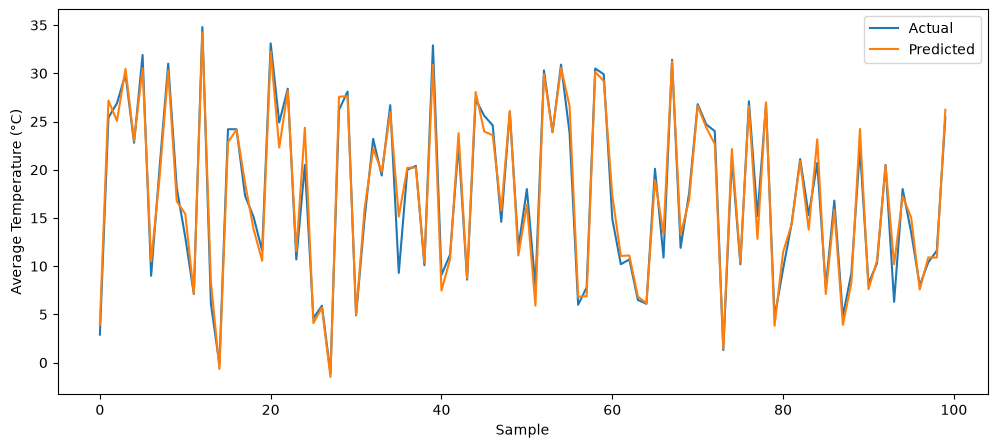

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.xlabel("Sample")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.show()

In [24]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef

,Feature,Coefficient
0,tmin,0.575008
1,tmax,0.392689
2,prcp,-0.029239
3,wspd,-0.116459
4,pres,-0.030998
5,month,0.029510


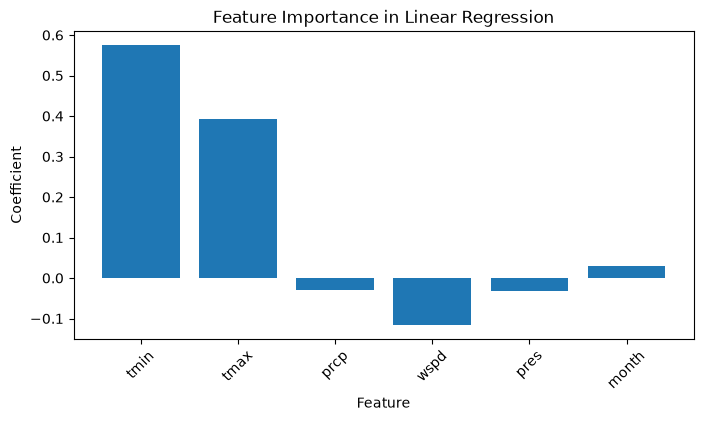

In [25]:
plt.figure(figsize=(8,4))

plt.bar(coef["Feature"], coef["Coefficient"])

plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Feature Importance in Linear Regression")

plt.xticks(rotation=45)

plt.show()

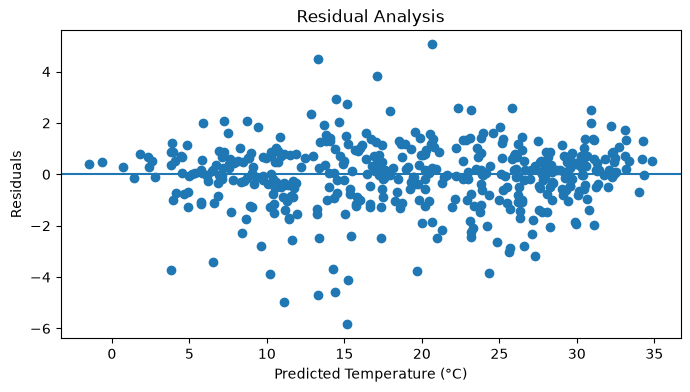

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals)

plt.xlabel("Predicted Temperature (°C)")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.axhline(0)
plt.show()

In [27]:
data["tavg_lag1"] = data["tavg"].shift(1)

data.head()

,date,tavg,tmin,tmax,prcp,wspd,pres,year,month,day,tavg_lag1
0,2020-01-01,7.8,-0.3,11.0,1.8,5.3,1032.2,2020,1,1,NaN
1,2020-01-02,9.7,1.2,11.3,0.0,4.9,1028.3,2020,1,2,7.8
2,2020-01-03,9.3,7.4,11.3,4.3,6.7,1027.3,2020,1,3,9.7
3,2020-01-04,9.6,8.7,10.1,0.0,6.8,1026.4,2020,1,4,9.3
4,2020-01-05,12.4,9.5,17.0,0.0,8.2,1024.7,2020,1,5,9.6


In [28]:
data = data.dropna()

In [29]:
data.head()

,date,tavg,tmin,tmax,prcp,wspd,pres,year,month,day,tavg_lag1
1,2020-01-02,9.7,1.2,11.3,0.0,4.9,1028.3,2020,1,2,7.8
2,2020-01-03,9.3,7.4,11.3,4.3,6.7,1027.3,2020,1,3,9.7
3,2020-01-04,9.6,8.7,10.1,0.0,6.8,1026.4,2020,1,4,9.3
4,2020-01-05,12.4,9.5,17.0,0.0,8.2,1024.7,2020,1,5,9.6
5,2020-01-06,15.3,9.0,24.0,0.0,5.9,1019.0,2020,1,6,12.4


In [30]:
X = data[
[
"tmin",
"tmax",
"prcp",
"wspd",
"pres",
"month",
"tavg_lag1"
]
]

y = data["tavg"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.64, 0.44,-0.03,...,-0.04, 0.04,-0.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['tmin','tmax','prcp',...,'pres','month','tavg_lag1']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.35
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [33]:
y_pred=model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, r2_score

MAE = mean_absolute_error(y_test, y_pred)

R2 = r2_score(y_test, y_pred)

print("MAE:", MAE)
print("R2:", R2)

MAE: 0.8531032331927743
R2: 0.9828348420177411


In [37]:
new_day = pd.DataFrame({
    "tmin": [28],
    "tmax": [40],
    "prcp": [0],
    "wspd": [3],
    "pres": [1002],
    "month": [8],
    "tavg_lag1": [31]
})

prediction = model.predict(new_day)

print("Predicted average temperature:", prediction[0], "°C")

Predicted average temperature: 33.92351594740258 °C


In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [40]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [41]:
y_pred_rf = rf_model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, r2_score

MAE_rf = mean_absolute_error(y_test, y_pred_rf)
R2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", MAE_rf)
print("Random Forest R2:", R2_rf)

Random Forest MAE: 0.8013735763097952
Random Forest R2: 0.9848770241507424


In [43]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,tmin,0.859030
1,tmax,0.101940
6,tavg_lag1,0.027900
3,wspd,0.004083
2,prcp,0.003058
4,pres,0.002773
5,month,0.001215


In [44]:
prediction_rf = rf_model.predict(new_day)

print(
    "Random Forest predicted temperature:",
    prediction_rf[0]
)

Random Forest predicted temperature: 33.94200000000002
